In [129]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('balls.jpg') # load image
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY) # convert to gray

blur = cv2.GaussianBlur(gray,(15,15),0) # apply blurring

_,otsu = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20,60))
closed = cv2.morphologyEx(otsu, cv2.MORPH_CROSS, kernel)

contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > 500]  # adjust this value

#Draw contours on original image
img_copy = img.copy()
cv2.drawContours(img_copy, filtered, -1, (0, 255, 0), 2)



array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

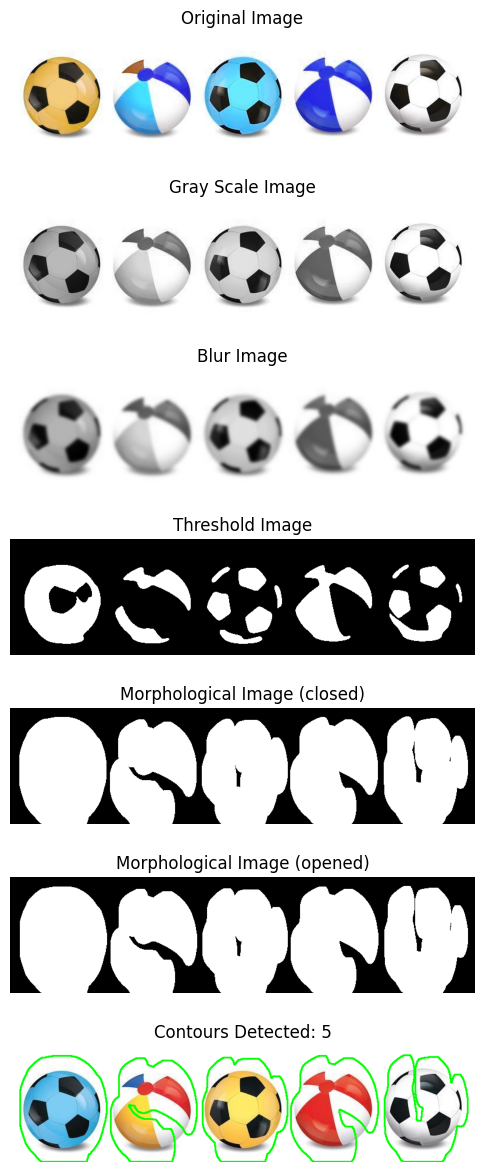

<Figure size 640x480 with 0 Axes>

In [130]:
plt.figure(figsize=(6, 15))  # Width x Height in inches

plt.subplot(7, 1, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(7, 1, 2)
plt.imshow(gray, cmap='gray')
plt.title("Gray Scale Image")
plt.axis('off')

plt.subplot(7, 1, 3)
plt.imshow(blur, cmap='gray')
plt.title("Blur Image")
plt.axis('off')

plt.subplot(7, 1, 4)
plt.imshow(otsu, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')

plt.subplot(7, 1, 5)
plt.imshow(closed, cmap='gray')
plt.title("Morphological Image (closed)")
plt.axis('off')

plt.subplot(7, 1, 6)
plt.imshow(opened, cmap='gray')
plt.title("Morphological Image (opened)")
plt.axis('off')

plt.subplot(7, 1, 7)
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title(f"Contours Detected: {len(filtered)}")
plt.axis('off')
plt.show()

plt.tight_layout()
plt.show()